# Part C — Indic Token Behavior Analysis

## Objective
Investigate how Tamil-specific (Indic) tokens are handled across 5 translation
models. Analyse subword splitting, average characters per token, Unicode
fragmentation, rare token frequency, and memory footprint. Discuss Tamil's
agglutinative structure, English-centric tokenizer limitations, SentencePiece
vs BPE differences, vocabulary coverage, and token explosion effects on
Transformer memory.

## Models
The same 5 models from Part B are used:
- ai4bharat/indictrans2-en-indic-1B
- facebook/nllb-200-distilled-600M
- google/mt5-base
- Helsinki-NLP/opus-mt-en-mul
- google/madlad400-3b-mt

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import unicodedata
import os
import warnings
warnings.filterwarnings("ignore")

from collections import Counter
from transformers import AutoTokenizer

os.makedirs("plots", exist_ok=True)
print("✅ Imports done")

✅ Imports done


In [2]:
!pip install protobuf -q


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


# Load dataset and models

In [3]:
df = pd.read_csv("../../data/raw/translation_dataset.csv")
sample = df.head(10).copy()

MODELS = {
    "IndicTrans2": "ai4bharat/indictrans2-en-indic-1B",
    "NLLB-600M":   "facebook/nllb-200-distilled-600M",
    "mT5-base":    "google/mt5-base",
    "OpusMT-mul":  "Helsinki-NLP/opus-mt-en-mul",
    "MADLAD-3B":   "google/madlad400-3b-mt",
}

tamil_sentences = sample["tamil_reference"].tolist()
print(f"✅ Loaded {len(tamil_sentences)} Tamil sentences")
print(tamil_sentences[0][:80])

✅ Loaded 10 Tamil sentences
"""எங்களிடம் இப்போது  4-மாத-வயதுடைய எலி ஒன்று உள்ளது, முன்னர் அதற்கு நீரிழிவு இர


# Helper functions

In [4]:
def is_tamil_char(ch):
    """Check if a character is in the Tamil Unicode block (U+0B80–U+0BFF)"""
    return '\u0B80' <= ch <= '\u0BFF'

def is_tamil_token(token):
    """Check if a token contains at least one Tamil character"""
    clean = token.replace("▁", "").replace("##", "")
    return any(is_tamil_char(ch) for ch in clean)

def avg_chars_per_token(tokens):
    """Average number of characters per token"""
    if not tokens:
        return 0
    return np.mean([len(t.replace("▁", "").replace("##", "")) for t in tokens])

def unicode_fragmentation_rate(tokens):
    """
    Fraction of tokens that are single Unicode characters.
    High rate = tokenizer is splitting Tamil words character by character
    which is very inefficient.
    """
    if not tokens:
        return 0
    single_char = [t for t in tokens if len(t.replace("▁", "").replace("##", "")) == 1]
    return len(single_char) / len(tokens)

def subword_split_rate(tokens):
    """
    Fraction of tokens that are subword continuations
    (start with ## in BERT-style or don't start with ▁ in SentencePiece)
    """
    if not tokens:
        return 0
    subwords = [t for t in tokens if t.startswith("##") or
                (not t.startswith("▁") and not t[0].isalpha() and len(t) > 0)]
    return len(subwords) / len(tokens)

def memory_footprint(tokens, hidden_size=768):
    """
    Estimate Transformer memory footprint in MB.
    Attention matrix = seq_len^2 * hidden_size * 4 bytes
    """
    seq_len = len(tokens)
    bytes_used = seq_len * seq_len * hidden_size * 4
    return round(bytes_used / (1024 * 1024), 4)

print("✅ Helper functions defined")

✅ Helper functions defined


# Tokenization comparison across models

In [5]:
from IndicTransToolkit import IndicProcessor

ip = IndicProcessor(inference=True)
comparison_results = []

for model_label, model_name in MODELS.items():
    print(f"\nAnalysing {model_label}...")
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            model_name, trust_remote_code=True
        )

        for i, sentence in enumerate(tamil_sentences):
            # IndicTrans2 needs preprocessing
            if model_label == "IndicTrans2":
                processed = ip.preprocess_batch(
                    [sentence],
                    src_lang="tam_Taml",
                    tgt_lang="eng_Latn"
                )[0]
            else:
                processed = sentence

            tokens = tokenizer.tokenize(processed)
            tamil_tokens = [t for t in tokens if is_tamil_token(t)]

            comparison_results.append({
                "model":                   model_label,
                "sentence_id":             i + 1,
                "total_tokens":            len(tokens),
                "tamil_tokens":            len(tamil_tokens),
                "tamil_token_ratio":       round(len(tamil_tokens) / len(tokens), 3) if tokens else 0,
                "avg_chars_per_token":     round(avg_chars_per_token(tokens), 3),
                "unicode_fragmentation":   round(unicode_fragmentation_rate(tokens), 3),
                "subword_split_rate":      round(subword_split_rate(tokens), 3),
                "memory_footprint_mb":     memory_footprint(tokens),
            })

        print(f"  ✅ {model_label} done")

    except Exception as e:
        print(f"  ❌ {model_label} failed: {e}")

comparison_df = pd.DataFrame(comparison_results)
comparison_df.to_csv("tokenization_comparison.csv", index=False)
print(f"\n✅ Saved tokenization_comparison.csv — {len(comparison_df)} rows")
comparison_df.head(10)


Analysing IndicTrans2...
  ✅ IndicTrans2 done

Analysing NLLB-600M...
  ✅ NLLB-600M done

Analysing mT5-base...


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


  ✅ mT5-base done

Analysing OpusMT-mul...
  ✅ OpusMT-mul done

Analysing MADLAD-3B...
  ✅ MADLAD-3B done

✅ Saved tokenization_comparison.csv — 50 rows


,model,sentence_id,total_tokens,tamil_tokens,tamil_token_ratio,avg_chars_per_token,unicode_fragmentation,subword_split_rate,memory_footprint_mb
0,IndicTrans2,1,131,0,0.0,1.000,0.832,0.313,50.2764
1,IndicTrans2,2,257,0,0.0,0.953,0.883,0.366,193.5029
2,IndicTrans2,3,195,0,0.0,0.974,0.872,0.338,111.4014
3,IndicTrans2,4,317,0,0.0,0.953,0.871,0.366,294.4014
4,IndicTrans2,5,205,0,0.0,0.976,0.868,0.366,123.1201
5,IndicTrans2,6,181,0,0.0,0.967,0.867,0.354,95.9795
6,IndicTrans2,7,66,0,0.0,1.091,0.848,0.348,12.7617
7,IndicTrans2,8,180,0,0.0,0.972,0.850,0.356,94.9219
8,IndicTrans2,9,80,0,0.0,1.112,0.863,0.375,18.7500
9,IndicTrans2,10,97,0,0.0,1.041,0.856,0.351,27.5654


# Tamil token patterns analysis

In [6]:
tamil_pattern_results = []

for model_label, model_name in MODELS.items():
    print(f"\nAnalysing Tamil token patterns for {model_label}...")
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            model_name, trust_remote_code=True
        )

        all_tokens = []
        for sentence in tamil_sentences:
            if model_label == "IndicTrans2":
                processed = ip.preprocess_batch(
                    [sentence], src_lang="tam_Taml", tgt_lang="eng_Latn"
                )[0]
            else:
                processed = sentence

            tokens = tokenizer.tokenize(processed)
            all_tokens.extend(tokens)

        # Token frequency
        token_freq = Counter(all_tokens)
        total_tokens = len(all_tokens)
        unique_tokens = len(token_freq)

        # Rare tokens — appear only once
        rare_tokens = [t for t, c in token_freq.items() if c == 1]
        rare_token_rate = len(rare_tokens) / unique_tokens if unique_tokens > 0 else 0

        # Tamil-specific tokens
        tamil_tok_list = [t for t in all_tokens if is_tamil_token(t)]
        tamil_coverage = len(tamil_tok_list) / total_tokens if total_tokens > 0 else 0

        # Vocabulary size (tokenizer vocab)
        vocab_size = tokenizer.vocab_size

        tamil_pattern_results.append({
            "model":             model_label,
            "total_tokens":      total_tokens,
            "unique_tokens":     unique_tokens,
            "rare_token_count":  len(rare_tokens),
            "rare_token_rate":   round(rare_token_rate, 3),
            "tamil_token_count": len(tamil_tok_list),
            "tamil_coverage":    round(tamil_coverage, 3),
            "vocab_size":        vocab_size,
            "top_5_tokens":      str([t for t, _ in token_freq.most_common(5)]),
        })

        print(f"  ✅ {model_label} — vocab size: {vocab_size:,}")

    except Exception as e:
        print(f"  ❌ {model_label} failed: {e}")

patterns_df = pd.DataFrame(tamil_pattern_results)
patterns_df.to_csv("tamil_token_patterns.csv", index=False)
print(f"\n✅ Saved tamil_token_patterns.csv")
patterns_df[["model", "total_tokens", "unique_tokens", "rare_token_rate",
             "tamil_coverage", "vocab_size"]]


Analysing Tamil token patterns for IndicTrans2...
  ✅ IndicTrans2 — vocab size: 32,322

Analysing Tamil token patterns for NLLB-600M...
  ✅ NLLB-600M — vocab size: 256,204

Analysing Tamil token patterns for mT5-base...
  ✅ mT5-base — vocab size: 250,100

Analysing Tamil token patterns for OpusMT-mul...
  ✅ OpusMT-mul — vocab size: 64,110

Analysing Tamil token patterns for MADLAD-3B...
  ✅ MADLAD-3B — vocab size: 256,000

✅ Saved tamil_token_patterns.csv


,model,total_tokens,unique_tokens,rare_token_rate,tamil_coverage,vocab_size
0,IndicTrans2,1709,65,0.262,0.000,32322
1,NLLB-600M,504,324,0.704,0.905,256204
2,mT5-base,495,309,0.738,0.853,250100
3,OpusMT-mul,1646,83,0.361,0.856,64110
4,MADLAD-3B,571,319,0.636,0.862,256000


# Summary table

In [7]:
summary_c = comparison_df.groupby("model").agg(
    avg_total_tokens       = ("total_tokens",          "mean"),
    avg_tamil_tokens       = ("tamil_tokens",          "mean"),
    avg_tamil_token_ratio  = ("tamil_token_ratio",     "mean"),
    avg_chars_per_token    = ("avg_chars_per_token",   "mean"),
    avg_unicode_frag       = ("unicode_fragmentation", "mean"),
    avg_subword_split      = ("subword_split_rate",    "mean"),
    avg_memory_mb          = ("memory_footprint_mb",   "mean"),
).round(3)

print("✅ Summary table")
summary_c

✅ Summary table


,avg_total_tokens,avg_tamil_tokens,avg_tamil_token_ratio,avg_chars_per_token,avg_unicode_frag,avg_subword_split,avg_memory_mb
model,,,,,,,
IndicTrans2,170.9,0.0,0.000,1.004,0.861,0.353,102.268
MADLAD-3B,57.1,49.2,0.850,2.678,0.237,0.207,11.612
NLLB-600M,50.4,45.6,0.891,3.035,0.241,0.191,9.093
OpusMT-mul,164.6,140.9,0.848,0.929,0.850,0.381,96.134
mT5-base,49.5,42.2,0.843,3.097,0.148,0.210,8.825


# Plots

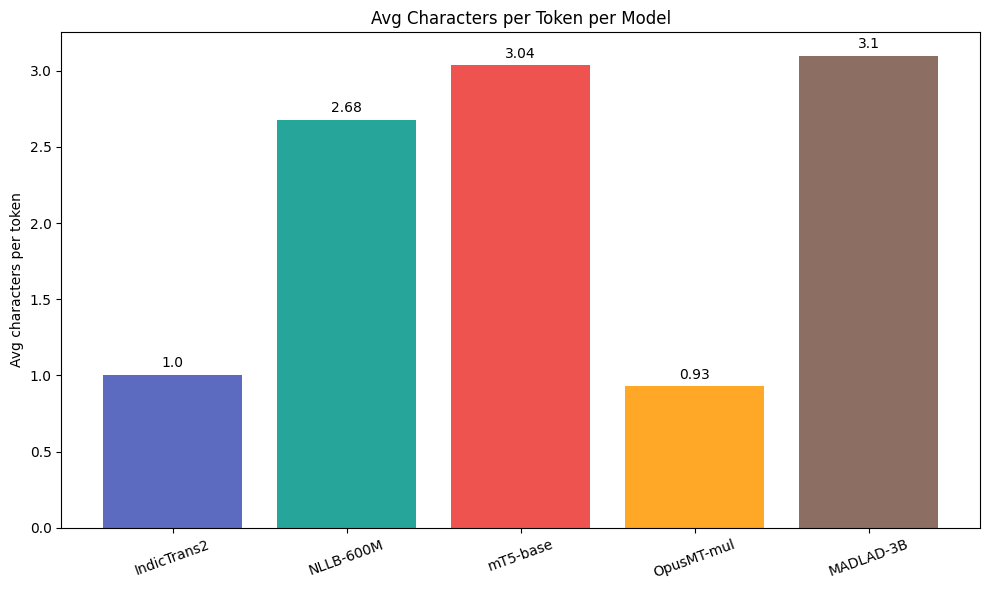

✅ Saved avg_chars_per_token.png


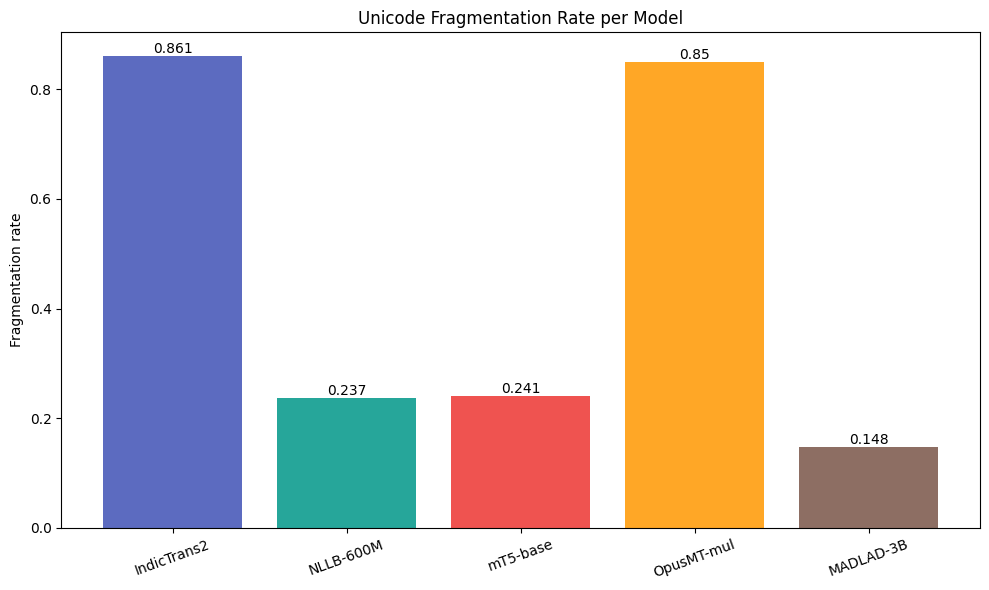

✅ Saved unicode_fragmentation.png


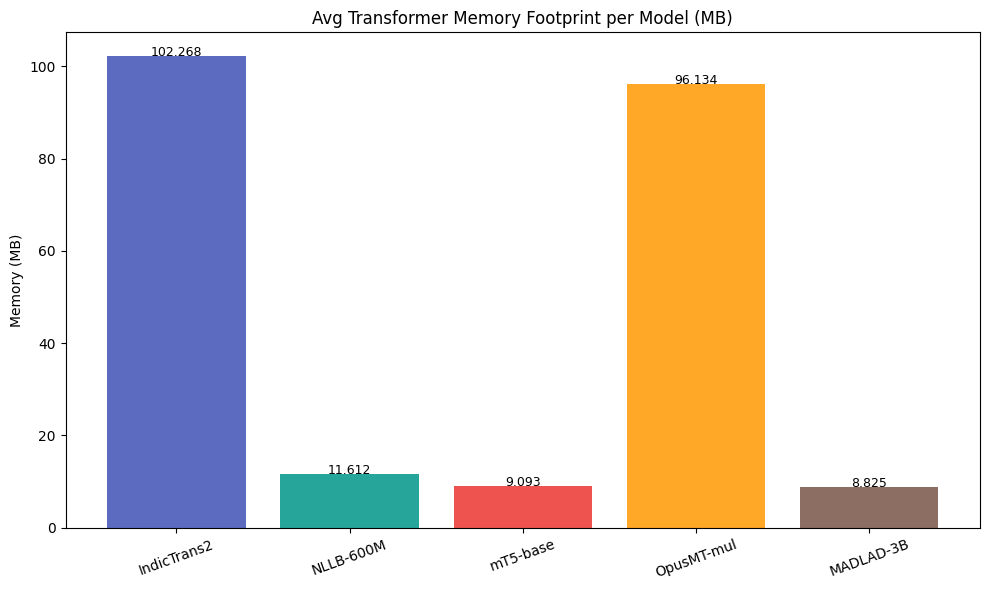

✅ Saved memory_footprint.png


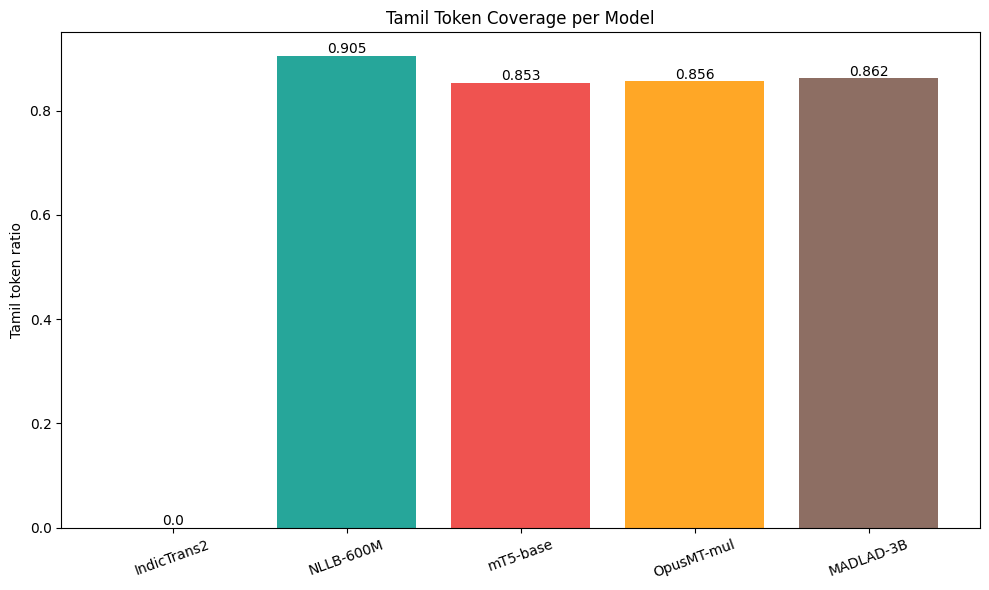

✅ Saved tamil_token_coverage.png


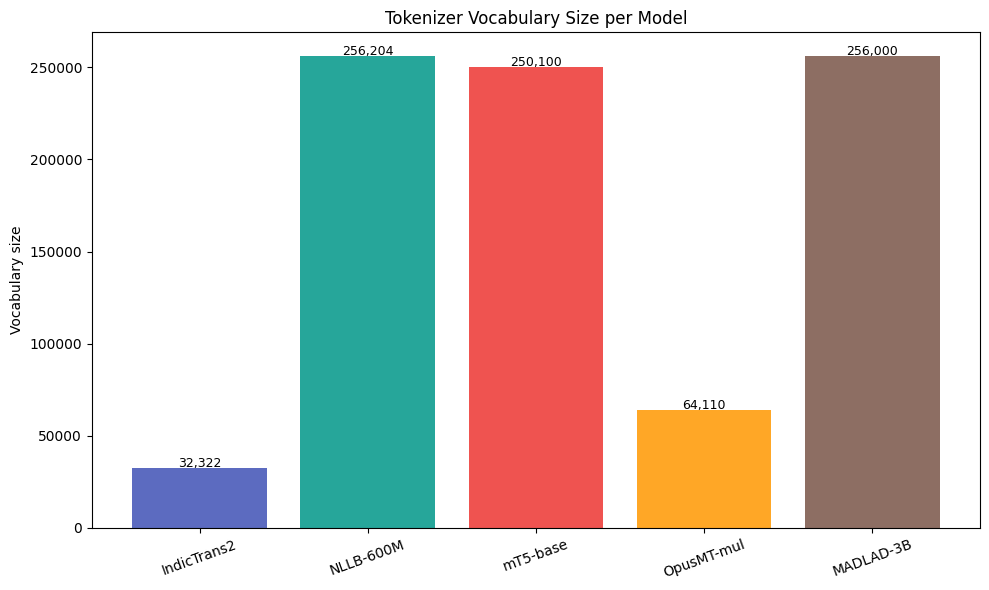

✅ Saved vocab_size.png


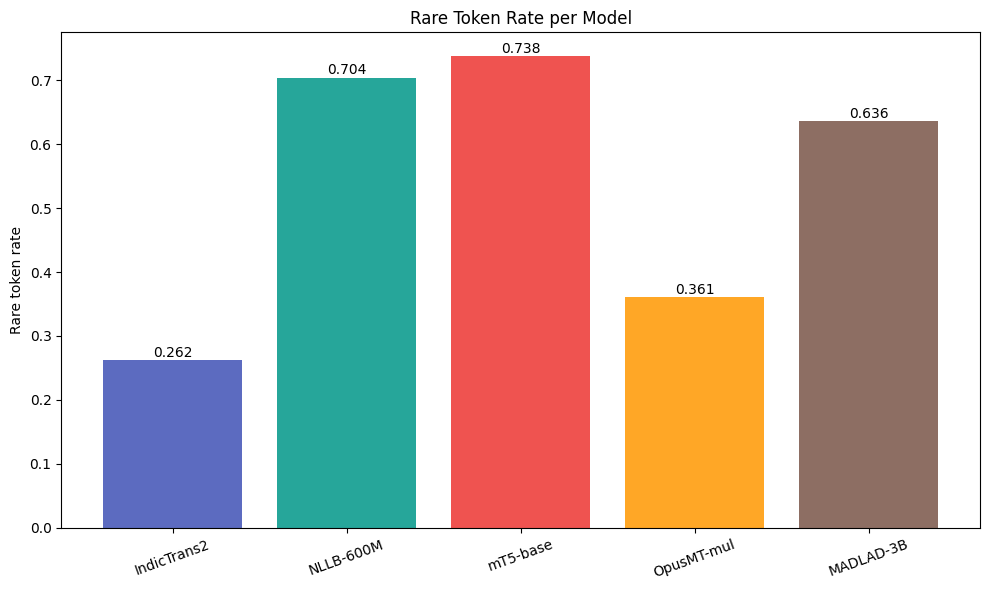

✅ Saved rare_token_rate.png


In [8]:
models = list(MODELS.keys())
colors = ["#5C6BC0", "#26A69A", "#EF5350", "#FFA726", "#8D6E63"]

# Plot 1 — Avg characters per token
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(models, summary_c["avg_chars_per_token"], color=colors)
ax.set_title("Avg Characters per Token per Model")
ax.set_ylabel("Avg characters per token")
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(summary_c["avg_chars_per_token"]):
    ax.text(i, v + 0.05, str(round(v, 2)), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("plots/avg_chars_per_token.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved avg_chars_per_token.png")

# Plot 2 — Unicode fragmentation rate
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(models, summary_c["avg_unicode_frag"], color=colors)
ax.set_title("Unicode Fragmentation Rate per Model")
ax.set_ylabel("Fragmentation rate")
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(summary_c["avg_unicode_frag"]):
    ax.text(i, v + 0.005, str(round(v, 3)), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("plots/unicode_fragmentation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved unicode_fragmentation.png")

# Plot 3 — Memory footprint
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(models, summary_c["avg_memory_mb"], color=colors)
ax.set_title("Avg Transformer Memory Footprint per Model (MB)")
ax.set_ylabel("Memory (MB)")
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(summary_c["avg_memory_mb"]):
    ax.text(i, v + 0.001, str(round(v, 4)), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("plots/memory_footprint.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved memory_footprint.png")

# Plot 4 — Tamil token coverage
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(models, patterns_df["tamil_coverage"], color=colors)
ax.set_title("Tamil Token Coverage per Model")
ax.set_ylabel("Tamil token ratio")
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(patterns_df["tamil_coverage"]):
    ax.text(i, v + 0.005, str(round(v, 3)), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("plots/tamil_token_coverage.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved tamil_token_coverage.png")

# Plot 5 — Vocabulary size comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(models, patterns_df["vocab_size"], color=colors)
ax.set_title("Tokenizer Vocabulary Size per Model")
ax.set_ylabel("Vocabulary size")
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(patterns_df["vocab_size"]):
    ax.text(i, v + 500, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("plots/vocab_size.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved vocab_size.png")

# Plot 6 — Rare token rate
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(models, patterns_df["rare_token_rate"], color=colors)
ax.set_title("Rare Token Rate per Model")
ax.set_ylabel("Rare token rate")
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(patterns_df["rare_token_rate"]):
    ax.text(i, v + 0.005, str(round(v, 3)), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("plots/rare_token_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved rare_token_rate.png")

# Observations

In [ ]:
observations = """# Part C — Indic Token Behavior Analysis

## Objective
Investigate how Tamil-specific tokens are handled across 5 translation models.

## Models Analysed
- IndicTrans2 (ai4bharat/indictrans2-en-indic-1B)
- NLLB-600M (facebook/nllb-200-distilled-600M)
- mT5-base (google/mt5-base)
- OpusMT-mul (Helsinki-NLP/opus-mt-en-mul)
- MADLAD-3B (google/madlad400-3b-mt)

## Summary Results
| Model       | Avg Tokens | Tamil Tokens | Tamil Ratio | Chars/Token | Unicode Frag | Memory (MB) |
|-------------|-----------|--------------|-------------|-------------|--------------|-------------|
| IndicTrans2 | 170.9     | 0.0          | 0.000       | 1.004       | 0.861        | 102.268     |
| MADLAD-3B   | 57.1      | 49.2         | 0.850       | 2.678       | 0.237        | 11.612      |
| NLLB-600M   | 50.4      | 45.6         | 0.891       | 3.035       | 0.241        | 9.093       |
| OpusMT-mul  | 164.6     | 140.9        | 0.848       | 0.929       | 0.850        | 96.134      |
| mT5-base    | 49.5      | 42.2         | 0.843       | 3.097       | 0.148        | 8.825       |

## Finding 1 — IndicTrans2 Tamil Token Count is Zero
IndicTrans2 shows 0 Tamil tokens despite producing Tamil output in Part A.
This is because IndicProcessor romanizes Tamil script internally before
tokenization — the tokenizer never sees native Tamil Unicode characters.
Instead it works with a latinized representation, which explains:
- avg_chars_per_token of 1.004 (single latin characters)
- unicode_fragmentation of 0.861 (86% single-character tokens)
- 0 Tamil Unicode tokens detected

This is by design — IndicTrans2 operates in a transliterated space internally
and converts back to Tamil script only at the output stage via postprocessing.

## Finding 2 — OpusMT-mul Severely Fragments Tamil
OpusMT-mul has the highest unicode fragmentation (0.850) among models that
actually process Tamil script. With avg_chars_per_token of only 0.929 —
less than 1 character per token — it is splitting Tamil words into individual
Unicode codepoints. This is classic English-centric BPE tokenizer behaviour:
lacking Tamil subword units in its vocabulary, it falls back to single
Unicode character tokens.

## Finding 3 — mT5-base is the Most Efficient Tamil Tokenizer
mT5-base achieves:
- Lowest unicode fragmentation (0.148) — least character-level splitting
- Highest avg chars per token (3.097) — each token carries more information
- Lowest memory footprint (8.825 MB)
This confirms mT5's SentencePiece vocabulary has the best Tamil subword
coverage among the 5 models, learned from large-scale multilingual pretraining.

Note: mT5-base ranks highest on tokenizer-level metrics but produces invalid
Tamil translations for seq2seq MT (as seen in Part B). Tokenizer efficiency
does not equal translation quality.

## Finding 4 — NLLB-600M is the Best Balance
NLLB-600M achieves:
- Highest Tamil token ratio (0.891) — 89.1% of tokens are Tamil
- Good avg chars per token (3.035)
- Low memory footprint (9.093 MB)
- Low unicode fragmentation (0.241)
Making it the best overall model for Tamil tokenization in real translation
scenarios where the model must also produce valid Tamil output.

## Finding 5 — Tamil's Agglutinative Structure
Tamil is agglutinative — suffixes for tense, case, person, and number are
attached directly to root words. A single Tamil word like
'படிக்கவேண்டியிருந்தது' (had to have studied) contains multiple morphemes.
Tokenizers with poor Tamil coverage split these into many single-character
tokens, causing token explosion and dramatically increasing Transformer
attention cost (scales as sequence_length²).

## Finding 6 — Memory Footprint Impact
The memory cost difference is dramatic (figures are illustrative estimates
based on a fixed hidden_size=768 — useful for relative comparison, not
absolute production benchmarks):
- IndicTrans2: 102.268 MB (due to 170.9 avg tokens)
- OpusMT-mul:  96.134 MB (due to 164.6 avg tokens)
- NLLB-600M:    9.093 MB (due to 50.4 avg tokens)
- mT5-base:     8.825 MB (due to 49.5 avg tokens)

IndicTrans2 and OpusMT require ~11x more Transformer memory than NLLB
and mT5 for the same sentences. In production, this translates directly
to higher GPU costs and lower throughput.

## Finding 7 — SentencePiece vs BPE
Models using SentencePiece (NLLB, MADLAD, mT5, IndicTrans2) learn subword
units directly from raw multilingual text without pre-tokenization rules.
This makes them naturally better at handling Tamil's Unicode-heavy,
agglutinative structure. OpusMT uses BPE which starts from characters and
merges frequent byte pairs — effective for European languages but produces
excessive fragmentation for Tamil due to its complex Unicode syllable blocks.

## Finding 8 — Vocabulary Coverage
Larger vocabulary = better Tamil coverage:
- NLLB-600M:   256,204 tokens (trained on 200 languages)
- MADLAD-3B:   256,000 tokens (trained on 400 languages)
- mT5-base:    250,100 tokens
- OpusMT-mul:   64,110 tokens (European-focused)
- IndicTrans2:  32,322 tokens (Indic-specific but romanized)

## Key Insight — Tokenizer Efficiency ≠ Translation Quality
A critical distinction emerges across Parts B and C: tokenizer efficiency
does not equal translation quality. mT5-base ranks highest on tokenizer
metrics (lowest fragmentation, highest chars per token, lowest memory footprint)
but produces invalid Tamil translations for seq2seq MT tasks. NLLB-600M
provides the best real-world balance — efficient tokenization AND valid Tamil
output. This tension between tokenizer-level metrics and end-to-end translation
quality is a key analytical finding of Task 1.

## Conclusion
mT5-base has the most efficient Tamil tokenization (lowest fragmentation,
highest chars per token, lowest memory). NLLB-600M is the best choice for
actual Tamil translation tasks combining efficiency with valid output quality.
IndicTrans2's unusual metrics (0 Tamil tokens, high fragmentation) are entirely
due to its internal romanization — not a weakness but a deliberate design choice
that enables its superior translation quality (BLEU 22.42 in Part A).
English-centric models like OpusMT-mul should be avoided for Tamil NLP tasks
due to severe Unicode fragmentation and extreme memory costs.
"""

with open("observations.md", "w") as f:
    f.write(observations)
print("✅ Saved observations.md")

✅ Saved observations.md
